In [1]:
# Import libraries
import tweepy
import pandas as pd
import requests
import io
import json
import re
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
# Enter your X/Twitter credentials here
consumer_key= "removed to prevent unauthorized access, unexpected billing charges, and compromised data security"
secret_key= "removed to prevent unauthorized access, unexpected billing charges, and compromised data security"
bearer_token="removed to prevent unauthorized access, unexpected billing charges, and compromised data security"

In [3]:
# Create Tweepy connection client
client = tweepy.Client( bearer_token=bearer_token, 
                        consumer_key=consumer_key, 
                        consumer_secret=secret_key, 
                        return_type = requests.Response,
                        wait_on_rate_limit=True)

In [4]:
# Define query as tweets from NBA's Twitter account(mostly retweets from the NBA Twitter account)
query = 'NBA is:retweet'

# get max. 100 tweets
tweets = client.search_recent_tweets(query=query, 
                                    tweet_fields=['author_id', 'text','created_at'], 
                                    expansions=['referenced_tweets.id'], 
                                    max_results=100)

In [5]:
# Save data as dictionary
tweets_dict = tweets.json() 

# Extract "data" value from dictionary
tweets_data = tweets_dict['data'] 

tweets_df=pd.DataFrame()

# Transform to pandas Dataframe
tweets_df = pd.json_normalize(tweets_data) 

In [6]:
# Disply dataframe
tweets_df

,text,created_at,edit_history_tweet_ids,author_id,id,referenced_tweets
0,RT @VidaVivaDiva: You’re telling me I have Lea...,2026-06-04T14:18:20.000Z,[2062539453088907773],933301717,2062539453088907773,"[{'type': 'retweeted', 'id': '2062341365577797..."
1,RT @NBA: THE BIGGEST STAGE IN BASKETBALL.\n \n...,2026-06-04T14:18:19.000Z,[2062539449267859929],885958969499541505,2062539449267859929,"[{'type': 'retweeted', 'id': '2062202658715492..."
2,RT @SbondyNBA: We have a Ron Baker jersey in t...,2026-06-04T14:18:19.000Z,[2062539447359394006],36858606,2062539447359394006,"[{'type': 'retweeted', 'id': '2062364916204306..."
3,RT @Thechat101: Paul Pierce tells Kevin Garnet...,2026-06-04T14:18:18.000Z,[2062539446768029722],1204521050668720138,2062539446768029722,"[{'type': 'retweeted', 'id': '2061955302962983..."
4,RT @NBA__Courtside: Jay Willams says Jalen Bru...,2026-06-04T14:18:18.000Z,[2062539445014868389],4135302574,2062539445014868389,"[{'type': 'retweeted', 'id': '2062524814472905..."
...,...,...,...,...,...,...
95,RT @Tyre_94: The Knicks versus the Spurs in th...,2026-06-04T14:17:35.000Z,[2062539262721949861],1395816916376244232,2062539262721949861,"[{'type': 'retweeted', 'id': '2062274452734328..."
96,RT @2KIntel: Me in NBA 2K27 after saying I’m d...,2026-06-04T14:17:33.000Z,[2062539258016203009],121676510,2062539258016203009,"[{'type': 'retweeted', 'id': '2062333567858864..."
97,RT @GuruLakers: This is NOT a troll. I’m NOT e...,2026-06-04T14:17:32.000Z,[2062539252894756897],1868320131354361856,2062539252894756897,"[{'type': 'retweeted', 'id': '2062378797610229..."
98,RT @espn: A cinematic opening at the start of ...,2026-06-04T14:17:32.000Z,[2062539251284414763],1869161152623849472,2062539251284414763,"[{'type': 'retweeted', 'id': '2062330553941021..."


In [7]:
# Transform referenced_tweets column to pandas Dataframe
referencedtweets_df = pd.json_normalize(tweets_df['referenced_tweets']) 

# Set column name
referencedtweets_df.columns=['referenced_tweets']

# Display dataframe
referencedtweets_df

,referenced_tweets
0,"{'type': 'retweeted', 'id': '20623413655777977..."
1,"{'type': 'retweeted', 'id': '20622026587154925..."
2,"{'type': 'retweeted', 'id': '20623649162043066..."
3,"{'type': 'retweeted', 'id': '20619553029629832..."
4,"{'type': 'retweeted', 'id': '20625248144729050..."
...,...
95,"{'type': 'retweeted', 'id': '20622744527343288..."
96,"{'type': 'retweeted', 'id': '20623335678588645..."
97,"{'type': 'retweeted', 'id': '20623787976102299..."
98,"{'type': 'retweeted', 'id': '20623305539410211..."


In [8]:
# Convert JSON results to data frame
referenceddf_new=pd.DataFrame(referencedtweets_df['referenced_tweets'].values.tolist())
referenceddf_new.rename(columns = {'id':'referenced_tweet_id'}, inplace = True)
referenceddf_new    

,type,referenced_tweet_id
0,retweeted,2062341365577797756
1,retweeted,2062202658715492558
2,retweeted,2062364916204306623
3,retweeted,2061955302962983229
4,retweeted,2062524814472905017
...,...,...
95,retweeted,2062274452734328889
96,retweeted,2062333567858864557
97,retweeted,2062378797610229929
98,retweeted,2062330553941021179


In [9]:
# Delete referenced_tweets column from tweets_df
del tweets_df['referenced_tweets'] 
# Delete referenced_tweets column
tweets_df

,text,created_at,edit_history_tweet_ids,author_id,id
0,RT @VidaVivaDiva: You’re telling me I have Lea...,2026-06-04T14:18:20.000Z,[2062539453088907773],933301717,2062539453088907773
1,RT @NBA: THE BIGGEST STAGE IN BASKETBALL.\n \n...,2026-06-04T14:18:19.000Z,[2062539449267859929],885958969499541505,2062539449267859929
2,RT @SbondyNBA: We have a Ron Baker jersey in t...,2026-06-04T14:18:19.000Z,[2062539447359394006],36858606,2062539447359394006
3,RT @Thechat101: Paul Pierce tells Kevin Garnet...,2026-06-04T14:18:18.000Z,[2062539446768029722],1204521050668720138,2062539446768029722
4,RT @NBA__Courtside: Jay Willams says Jalen Bru...,2026-06-04T14:18:18.000Z,[2062539445014868389],4135302574,2062539445014868389
...,...,...,...,...,...
95,RT @Tyre_94: The Knicks versus the Spurs in th...,2026-06-04T14:17:35.000Z,[2062539262721949861],1395816916376244232,2062539262721949861
96,RT @2KIntel: Me in NBA 2K27 after saying I’m d...,2026-06-04T14:17:33.000Z,[2062539258016203009],121676510,2062539258016203009
97,RT @GuruLakers: This is NOT a troll. I’m NOT e...,2026-06-04T14:17:32.000Z,[2062539252894756897],1868320131354361856,2062539252894756897
98,RT @espn: A cinematic opening at the start of ...,2026-06-04T14:17:32.000Z,[2062539251284414763],1869161152623849472,2062539251284414763


In [10]:
# Combine two dataframes together by column
new_tweets_df=pd.concat([tweets_df,referenceddf_new], axis=1)        
new_tweets_df

,text,created_at,edit_history_tweet_ids,author_id,id,type,referenced_tweet_id
0,RT @VidaVivaDiva: You’re telling me I have Lea...,2026-06-04T14:18:20.000Z,[2062539453088907773],933301717,2062539453088907773,retweeted,2062341365577797756
1,RT @NBA: THE BIGGEST STAGE IN BASKETBALL.\n \n...,2026-06-04T14:18:19.000Z,[2062539449267859929],885958969499541505,2062539449267859929,retweeted,2062202658715492558
2,RT @SbondyNBA: We have a Ron Baker jersey in t...,2026-06-04T14:18:19.000Z,[2062539447359394006],36858606,2062539447359394006,retweeted,2062364916204306623
3,RT @Thechat101: Paul Pierce tells Kevin Garnet...,2026-06-04T14:18:18.000Z,[2062539446768029722],1204521050668720138,2062539446768029722,retweeted,2061955302962983229
4,RT @NBA__Courtside: Jay Willams says Jalen Bru...,2026-06-04T14:18:18.000Z,[2062539445014868389],4135302574,2062539445014868389,retweeted,2062524814472905017
...,...,...,...,...,...,...,...
95,RT @Tyre_94: The Knicks versus the Spurs in th...,2026-06-04T14:17:35.000Z,[2062539262721949861],1395816916376244232,2062539262721949861,retweeted,2062274452734328889
96,RT @2KIntel: Me in NBA 2K27 after saying I’m d...,2026-06-04T14:17:33.000Z,[2062539258016203009],121676510,2062539258016203009,retweeted,2062333567858864557
97,RT @GuruLakers: This is NOT a troll. I’m NOT e...,2026-06-04T14:17:32.000Z,[2062539252894756897],1868320131354361856,2062539252894756897,retweeted,2062378797610229929
98,RT @espn: A cinematic opening at the start of ...,2026-06-04T14:17:32.000Z,[2062539251284414763],1869161152623849472,2062539251284414763,retweeted,2062330553941021179


In [11]:
original_authors=pd.DataFrame(columns=['original_author']) # Create empty data frame

RT='RT @'
Colon=":"

# for loop that retrieves the string that matches 'RT @' and ':' and then add it as new row to data frame
for i in new_tweets_df.index:
    original_author=re.match("RT @\w+:", new_tweets_df['text'][i]).group(0) # find matching substring
    original_author=original_author.replace(RT,"")         # delete "RT @"
    original_author=original_author.replace(Colon,"")      # delete ":"
    new_row=pd.DataFrame([{'original_author': original_author}])   # create one new row as data frame
    original_authors=pd.concat([original_authors, new_row], axis=0, ignore_index=True)  # add new row to combined data frame

original_authors

,original_author
0,VidaVivaDiva
1,NBA
2,SbondyNBA
3,Thechat101
4,NBA__Courtside
...,...
95,Tyre_94
96,2KIntel
97,GuruLakers
98,espn


In [12]:
# Combine two dataframes together by column
new_tweets_df=pd.concat([tweets_df,original_authors], axis=1)        
new_tweets_df

,text,created_at,edit_history_tweet_ids,author_id,id,original_author
0,RT @VidaVivaDiva: You’re telling me I have Lea...,2026-06-04T14:18:20.000Z,[2062539453088907773],933301717,2062539453088907773,VidaVivaDiva
1,RT @NBA: THE BIGGEST STAGE IN BASKETBALL.\n \n...,2026-06-04T14:18:19.000Z,[2062539449267859929],885958969499541505,2062539449267859929,NBA
2,RT @SbondyNBA: We have a Ron Baker jersey in t...,2026-06-04T14:18:19.000Z,[2062539447359394006],36858606,2062539447359394006,SbondyNBA
3,RT @Thechat101: Paul Pierce tells Kevin Garnet...,2026-06-04T14:18:18.000Z,[2062539446768029722],1204521050668720138,2062539446768029722,Thechat101
4,RT @NBA__Courtside: Jay Willams says Jalen Bru...,2026-06-04T14:18:18.000Z,[2062539445014868389],4135302574,2062539445014868389,NBA__Courtside
...,...,...,...,...,...,...
95,RT @Tyre_94: The Knicks versus the Spurs in th...,2026-06-04T14:17:35.000Z,[2062539262721949861],1395816916376244232,2062539262721949861,Tyre_94
96,RT @2KIntel: Me in NBA 2K27 after saying I’m d...,2026-06-04T14:17:33.000Z,[2062539258016203009],121676510,2062539258016203009,2KIntel
97,RT @GuruLakers: This is NOT a troll. I’m NOT e...,2026-06-04T14:17:32.000Z,[2062539252894756897],1868320131354361856,2062539252894756897,GuruLakers
98,RT @espn: A cinematic opening at the start of ...,2026-06-04T14:17:32.000Z,[2062539251284414763],1869161152623849472,2062539251284414763,espn


In [13]:
# Create Tweept connection client for collecting retweeter user info
retweetclient = tweepy.Client(bearer_token=bearer_token, wait_on_rate_limit=True)

In [14]:
retweet_authors=pd.DataFrame(columns=['retweet_author']) # Create empty data frame

# for loop that retrieves the screen name based on Twitter ID and then add it as new row to data frame
for i in new_tweets_df.index:
    retweeter_id=new_tweets_df['author_id'][i]
    retweet_author=retweetclient.get_user(id=retweeter_id).data.username # find screen name based on Twitter ID
    new_row=pd.DataFrame([{'retweet_author': retweet_author}])   # create one new row as data frame
    retweet_authors=pd.concat([retweet_authors, new_row], axis=0, ignore_index=True)  # add new row to combined data frame

retweet_authors

,retweet_author
0,JOSHHHH718
1,DOITFORDOMB
2,Metsochist4Life
3,bearstewart17
4,215Angel_Smoove
...,...
95,tweetsbytyre
96,BigRusays
97,WheezyFBaby_
98,Spider_Van245


In [15]:
# Combine two dataframes together by column
new_tweets_df=pd.concat([new_tweets_df,retweet_authors], axis=1)        
new_tweets_df

,text,created_at,edit_history_tweet_ids,author_id,id,original_author,retweet_author
0,RT @VidaVivaDiva: You’re telling me I have Lea...,2026-06-04T14:18:20.000Z,[2062539453088907773],933301717,2062539453088907773,VidaVivaDiva,JOSHHHH718
1,RT @NBA: THE BIGGEST STAGE IN BASKETBALL.\n \n...,2026-06-04T14:18:19.000Z,[2062539449267859929],885958969499541505,2062539449267859929,NBA,DOITFORDOMB
2,RT @SbondyNBA: We have a Ron Baker jersey in t...,2026-06-04T14:18:19.000Z,[2062539447359394006],36858606,2062539447359394006,SbondyNBA,Metsochist4Life
3,RT @Thechat101: Paul Pierce tells Kevin Garnet...,2026-06-04T14:18:18.000Z,[2062539446768029722],1204521050668720138,2062539446768029722,Thechat101,bearstewart17
4,RT @NBA__Courtside: Jay Willams says Jalen Bru...,2026-06-04T14:18:18.000Z,[2062539445014868389],4135302574,2062539445014868389,NBA__Courtside,215Angel_Smoove
...,...,...,...,...,...,...,...
95,RT @Tyre_94: The Knicks versus the Spurs in th...,2026-06-04T14:17:35.000Z,[2062539262721949861],1395816916376244232,2062539262721949861,Tyre_94,tweetsbytyre
96,RT @2KIntel: Me in NBA 2K27 after saying I’m d...,2026-06-04T14:17:33.000Z,[2062539258016203009],121676510,2062539258016203009,2KIntel,BigRusays
97,RT @GuruLakers: This is NOT a troll. I’m NOT e...,2026-06-04T14:17:32.000Z,[2062539252894756897],1868320131354361856,2062539252894756897,GuruLakers,WheezyFBaby_
98,RT @espn: A cinematic opening at the start of ...,2026-06-04T14:17:32.000Z,[2062539251284414763],1869161152623849472,2062539251284414763,espn,Spider_Van245


In [16]:
# Merge retweet_author and original_author into one data frame
retweets_df=pd.concat([new_tweets_df['retweet_author'],new_tweets_df['original_author']], axis=1) 
retweets_df                                                            

,retweet_author,original_author
0,JOSHHHH718,VidaVivaDiva
1,DOITFORDOMB,NBA
2,Metsochist4Life,SbondyNBA
3,bearstewart17,Thechat101
4,215Angel_Smoove,NBA__Courtside
...,...,...
95,tweetsbytyre,Tyre_94
96,BigRusays,2KIntel
97,WheezyFBaby_,GuruLakers
98,Spider_Van245,espn


In [17]:
# Save results to Excel
retweets_df.to_excel(r'NBA retweet network.xlsx', index=False)

In [18]:
# Create network graph based on edge list
nba_retweet_graph = nx.from_pandas_edgelist(retweets_df, source='retweet_author', target='original_author', create_using=nx.DiGraph)

# Remove self ties
nba_retweet_graph.remove_edges_from(nx.selfloop_edges(nba_retweet_graph))

# length of graph (i.e., number of nodes)
len(nba_retweet_graph.nodes())

143

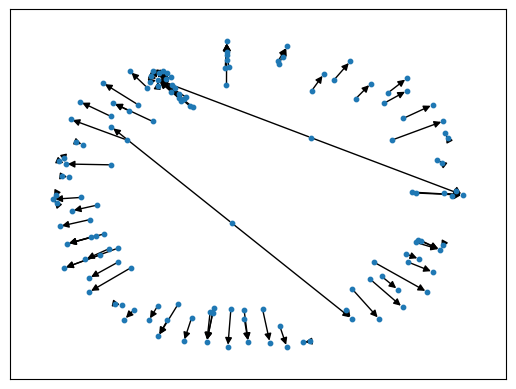

In [19]:
# Draw the retweet network with the default fruchterman Reingold layout
nx.draw_networkx(nba_retweet_graph, with_labels = False, node_size=10)

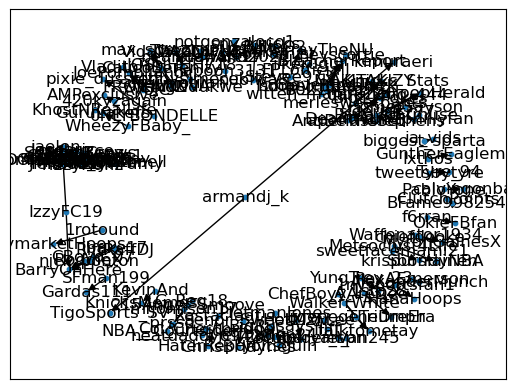

In [29]:
# Draw the network with default layout and node labels
nx.draw_networkx(nba_retweet_graph, with_labels = True, node_size=10)

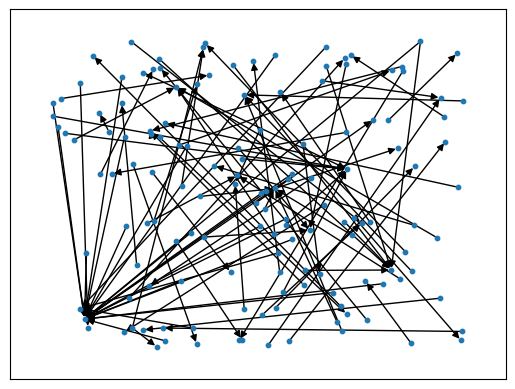

In [21]:
# Random layout
nx.draw_networkx(nba_retweet_graph, with_labels = False, 
        pos=nx.random_layout(nba_retweet_graph), node_size=10)

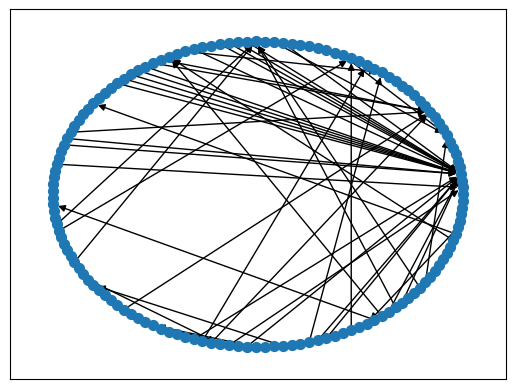

In [22]:
# Circular layout
nx.draw_networkx(nba_retweet_graph, with_labels = False, 
        pos=nx.circular_layout(nba_retweet_graph), node_size=50)

In [23]:
# Calculate in and out degree centralities for directed retweet network
in_deg_centrality = nx.in_degree_centrality(nba_retweet_graph)
out_deg_centrality = nx.out_degree_centrality(nba_retweet_graph)
# deg_centrality = nx.degree_centrality(nba_retweet_graph) Use this one if the network is undirected

# closeness centrality
close_centrality = nx.closeness_centrality(nba_retweet_graph)

# betweenness centrality
bet_centrality = nx.betweenness_centrality(nba_retweet_graph)

#eigenvector centrality
eigen_centrality = nx.eigenvector_centrality(nba_retweet_graph,max_iter=1000)  # Increase the max_iter parameter if the calculation does not converge


In [24]:
# Calculate and organize results as a data frame
centrality_df = pd.DataFrame(dict(
    indegree_centrality       = nx.in_degree_centrality(nba_retweet_graph),
    outdegree_centrality      = nx.out_degree_centrality(nba_retweet_graph),
    closeness_centrality      = nx.closeness_centrality(nba_retweet_graph),
    betweenness_centrality    = nx.betweenness_centrality(nba_retweet_graph),
    eigenvector_centrality    = nx.eigenvector_centrality(nba_retweet_graph, max_iter=1000), # Increase the max_iter parameter if the calculation does not converge
))

In [25]:
centrality_df

,indegree_centrality,outdegree_centrality,closeness_centrality,betweenness_centrality,eigenvector_centrality
JOSHHHH718,0.000000,0.007042,0.000000,0.0,0.000210
VidaVivaDiva,0.021127,0.000000,0.021127,0.0,0.123825
DOITFORDOMB,0.000000,0.007042,0.000000,0.0,0.000210
NBA,0.140845,0.000000,0.140845,0.0,0.824308
Metsochist4Life,0.000000,0.007042,0.000000,0.0,0.000210
...,...,...,...,...,...
WheezyFBaby_,0.000000,0.007042,0.000000,0.0,0.000210
Spider_Van245,0.000000,0.007042,0.000000,0.0,0.000210
espn,0.007042,0.000000,0.007042,0.0,0.041415
420kyzagain,0.000000,0.007042,0.000000,0.0,0.000210


In [26]:
# Save results to Excel; index=True specifies saving the index (i.e., Twitter user names) as well
centrality_df.to_excel(r'NBA retweet network centralities.xlsx', index=True)